完成合并十大诈骗类型：
fraud_type
虚假购物服务类诈骗        401
虚假网络投资理财类诈骗      297
网络婚恋、交友类诈骗       206
冒充公检法及政府机关类诈骗    141
冒充电商物流客服类诈骗       98
冒充领导熟人类诈骗         67
虚假贷款类诈骗           54
刷单返利类诈骗           48
网络游戏产品虚假交易类诈骗     18
虚假征信类诈骗            9
Name: count, dtype: int64
模型总体准确率 (Accuracy): 0.3843

               precision    recall  f1-score   support

冒充公检法及政府机关类诈骗       0.59      0.38      0.46        34
  冒充电商物流客服类诈骗       0.38      0.53      0.44        19
    冒充领导熟人类诈骗       0.07      0.12      0.09         8
      刷单返利类诈骗       0.04      0.08      0.05        13
   网络婚恋、交友类诈骗       0.41      0.35      0.38        34
网络游戏产品虚假交易类诈骗       0.43      0.60      0.50         5
      虚假征信类诈骗       0.00      0.00      0.00         2
  虚假网络投资理财类诈骗       0.49      0.49      0.49        69
    虚假购物服务类诈骗       0.58      0.39      0.47        74
      虚假贷款类诈骗       0.00      0.00      0.00        10

     accuracy                           0.38       268
    macro avg       0.30      0.29      0.29       

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6732\980956284.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Dimension', data=grouped_df, palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6732\980956284.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='mako')


任务完成🎉


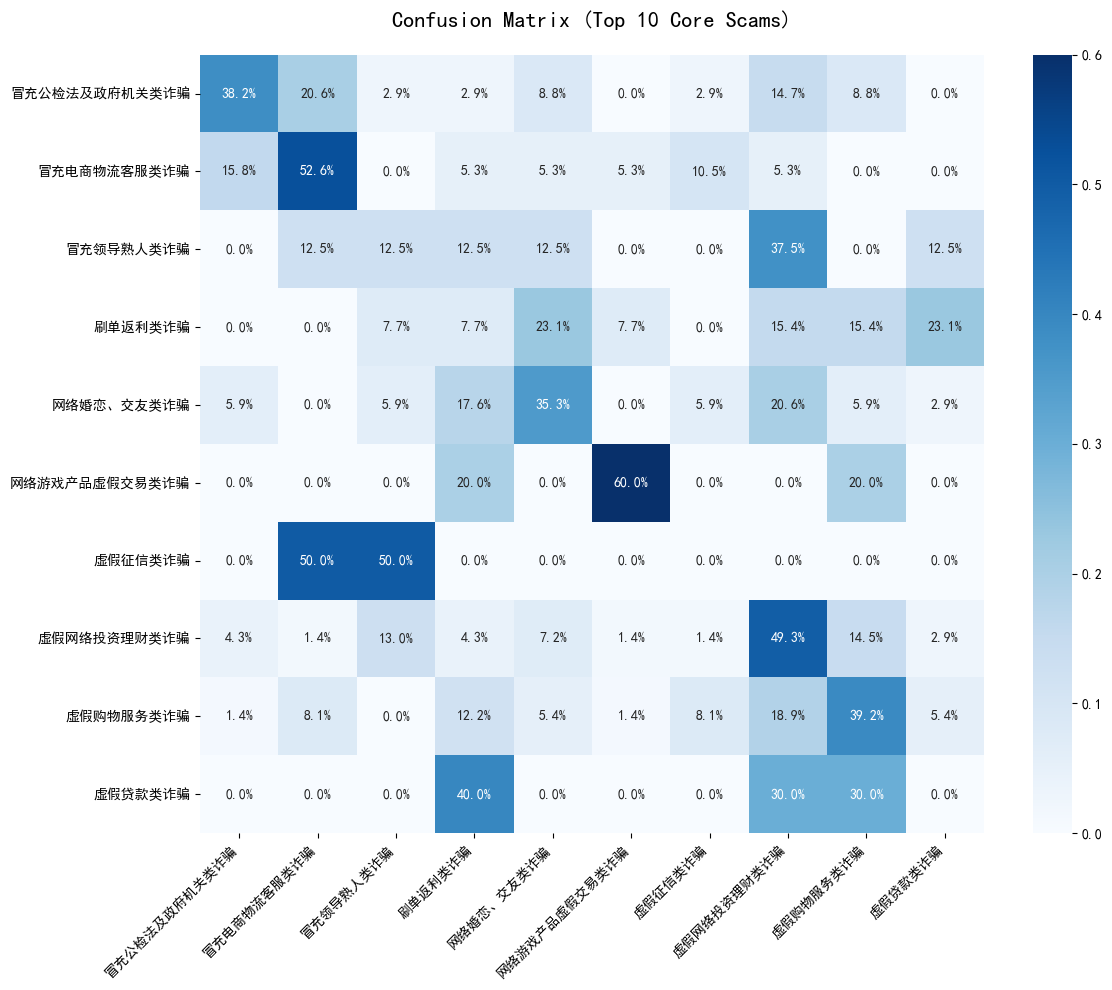

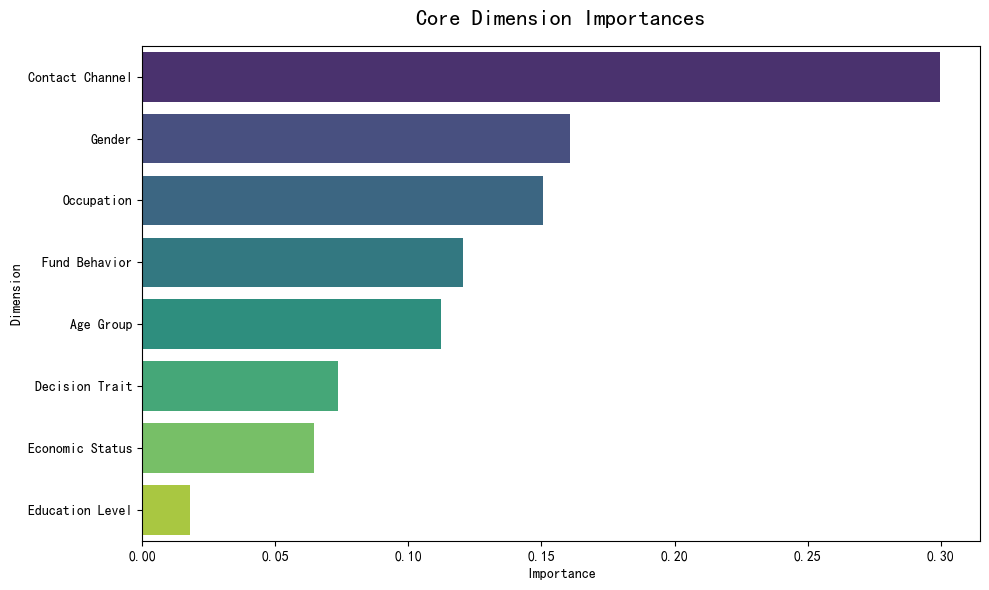

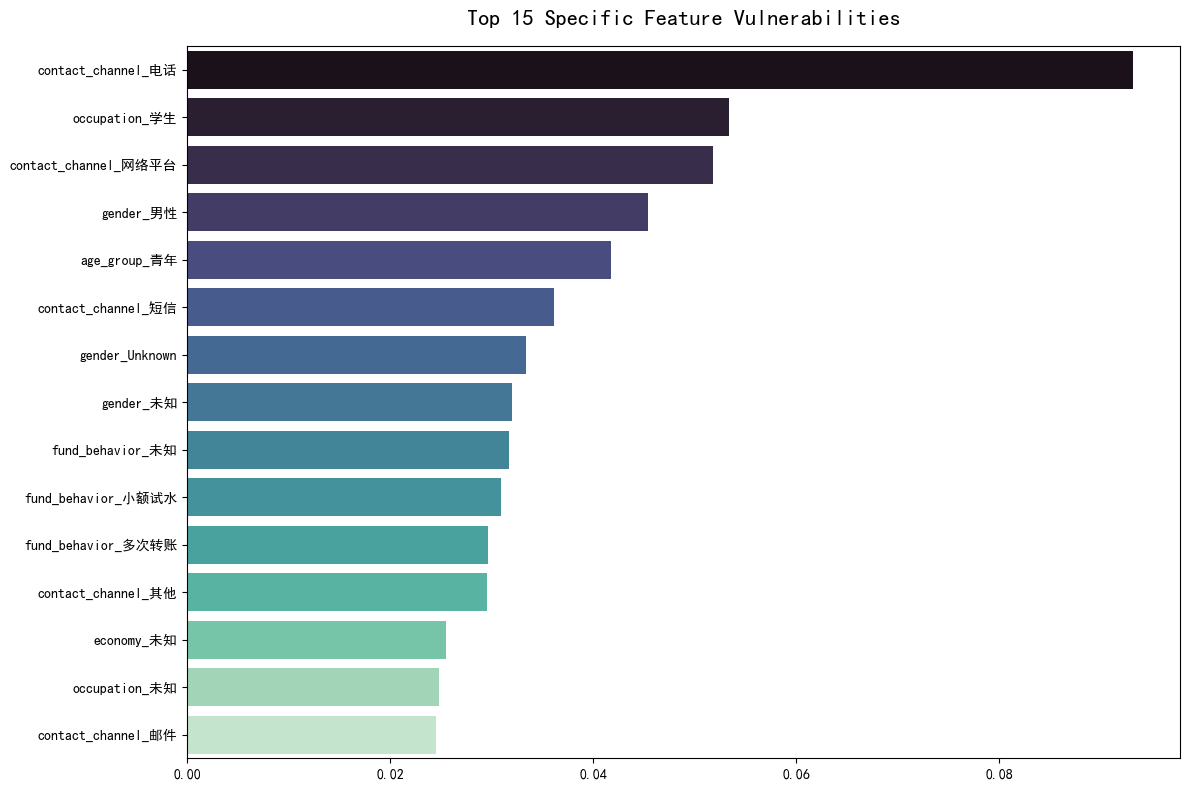

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import platform

#设置中文字体
if platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
elif platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang HK']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False


#加载数据 (自动兼容 WPS/Excel 编码)

def read_safe(filename):
    try:
        return pd.read_csv(filename, encoding='utf-8-sig')
    except:
        return pd.read_csv(filename, encoding='gbk', encoding_errors='ignore')

df_news = read_safe('news final.csv')
df_post = read_safe('post_fixed.csv')

# 合并数据
df_merged = pd.concat([df_news, df_post], ignore_index=True)
df_merged['fraud_type'] = df_merged['fraud_type'].astype(str).str.strip().str.lower()

# 删除其他和未知分类
drop_keywords = ['其他', 'other', '未知', 'unknown', '新型']
mask = df_merged['fraud_type'].apply(lambda x: not any(k in x for k in drop_keywords))
df_clean = df_merged[mask].copy()


# 按照公安部十大诈骗类型分类
def map_top_10(x):
    # 按照业务逻辑优先级进行关键词检索
    if '刷单' in x or '返利' in x or 'brush' in x: 
        return '刷单返利类诈骗'
    if '投资' in x or '理财' in x or 'invest' in x: 
        return '虚假网络投资理财类诈骗'
    if '客服' in x or '物流' in x: 
        return '冒充电商物流客服类诈骗' 
    
    # 把招商、招聘、教育、医疗等全部归为虚假购物服务类
    if '购物' in x or '电商' in x or 'commerce' in x or '招商' in x or '加盟' in x or '招聘' in x or '求职' in x or '教育' in x or '培训' in x or '招生' in x or '医疗' in x or '健康' in x or '服务' in x: 
        return '虚假购物服务类诈骗'
        
    if '征信' in x: 
        return '虚假征信类诈骗' 
    if '贷款' in x or '信用' in x or 'loan' in x: 
        return '虚假贷款类诈骗'
    if '领导' in x or '熟人' in x or 'acquaintance' in x: 
        return '冒充领导熟人类诈骗'
    if '公检法' in x or '政府' in x or '警察' in x or '银行' in x: 
        return '冒充公检法及政府机关类诈骗'
    if '婚恋' in x or '交友' in x or '杀猪盘' in x or 'romance' in x: 
        return '网络婚恋、交友类诈骗'
    if '游戏' in x or 'game' in x: 
        return '网络游戏产品虚假交易类诈骗'
    
    # 无法识别则剔除
    return 'UNMAPPED'

df_clean['mapped_type'] = df_clean['fraud_type'].apply(map_top_10)

# 剔除未匹配的数据（
df_final = df_clean[df_clean['mapped_type'] != 'UNMAPPED'].copy()
df_final['fraud_type'] = df_final['mapped_type']

print("完成合并十大诈骗类型：")
print(df_final['fraud_type'].value_counts())
print("="*60)

# 提取特征并导出最终的 CSV 文件
features = [
    'contact_channel', 'age_group', 'gender', 
    'education_level', 'occupation', 'economy', 
    'fund_behavior', 'decision_trait'
]

df_model = df_final[features + ['fraud_type']].copy().fillna('Unknown')
# 导出最终的完美融合版 CSV
df_model.to_csv('final_top10_model_data_merged.csv', index=False, encoding='utf-8-sig')


# 模型训练与评估
le = LabelEncoder()
y = le.fit_transform(df_model['fraud_type'])
X = pd.get_dummies(df_model[features])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 使用代价敏感学习 (balanced) 保护罕见大案
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=3, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"模型总体准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. 生成 3 张可视化图表
# 图 1：混淆矩阵
cm = confusion_matrix(y_test, y_pred)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_perc = np.nan_to_num(cm_perc)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.1%', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Top 10 Core Scams)', fontsize=16, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('1_confusion_matrix_Top10_merged.png', dpi=300)

# 图 2：宏观 8 大维度权重
importances = rf_model.feature_importances_
feature_names = X.columns
grouped_importances = {feat: 0.0 for feat in features}
for col, imp in zip(feature_names, importances):
    for feat in features:
        if col.startswith(feat + '_'):
            grouped_importances[feat] += imp
            break
grouped_df = pd.DataFrame(list(grouped_importances.items()), columns=['Dimension', 'Importance'])
grouped_df = grouped_df.sort_values(by='Importance', ascending=False)
display_names = {
    'contact_channel': 'Contact Channel', 'age_group': 'Age Group', 'gender': 'Gender',
    'education_level': 'Education Level', 'occupation': 'Occupation', 'economy': 'Economic Status',
    'fund_behavior': 'Fund Behavior', 'decision_trait': 'Decision Trait'
}
grouped_df['Dimension'] = grouped_df['Dimension'].map(display_names)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Dimension', data=grouped_df, palette='viridis')
plt.title('Core Dimension Importances', fontsize=16, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('2_core_dimension_Top10_merged.png', dpi=300)

# 图 3：微观 Top 15 具体特征
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='mako')
plt.title('Top 15 Specific Feature Vulnerabilities', fontsize=16, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('3_top15_features_Top10_merged.png', dpi=300)

print("任务完成🎉")